# Task 2 — Trends, and the spaghetti problem

**Data Visualization — Week 1 assignment, Task 2** · dataset: `data/gapminder.csv`

142 countries × 12 years (1952–2007). The plan:

| Step | What I do |
|---|---|
| 1 | Build the messy chart on purpose — 142 lines and a 142-entry legend — and list what is wrong with it |
| 2a | Fix it by **aggregating**: one line per continent |
| 2b | Fix it by **highlighting**: 142 grey lines, 3 coloured and labelled countries |
| 3 | Compare what (a) and (b) can and cannot show |
| — | Deal with the skew in `gdpPercap` (histogram, linear vs log) |
| 4 | One chart: *has the gap between the richest and poorest countries narrowed since 1952?* |

## 0. Setup

Same house style as the lecture notebook: the eight-hue colour-blind-safe palette, recessive grid, no chart
border, titles on the left. Every chart below inherits it, and every chart is also saved to `charts/`.

I added one small helper, `footnote()`, because several charts in this task have to **declare excluded
rows on the chart itself**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (same as the lecture) ---------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]

INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

# ---- House style ---------------------------------------------------
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    # Every chart is also exported to charts/ so it can go straight into a report.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)


def footnote(ax, text, y=-0.18):
    # Small grey note under the chart - used to declare exclusions ON the chart.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


---

# Meet the data

In [2]:
gap = pd.read_csv(DATA / "gapminder.csv")
print("Rows:", gap.shape[0], " Columns:", gap.shape[1])
print("Countries:", gap["country"].nunique(), " Years:", sorted(gap["year"].unique()))
print("Missing values:", int(gap.isna().sum().sum()))
print("Rows per country:", gap["country"].value_counts().unique())
gap.head()

Rows: 1704  Columns: 6
Countries: 142  Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Missing values: 0
Rows per country: [12]


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


In [3]:
# Countries per continent - this matters later: Oceania is only two countries.
gap.drop_duplicates("country")["continent"].value_counts().to_frame("countries")

,countries
continent,
Africa,52
Asia,33
Europe,30
Americas,25
Oceania,2


A balanced panel — every country has all 12 years and nothing is missing — so no rows are excluded anywhere
in this notebook.

---

# Step 1 — The messy chart, on purpose

> ⚠️ **This chart is deliberately bad.** It is here to be criticised, not copied.

Life expectancy over time, one line per country, all 142 of them, with matplotlib's default colours and a full
legend.

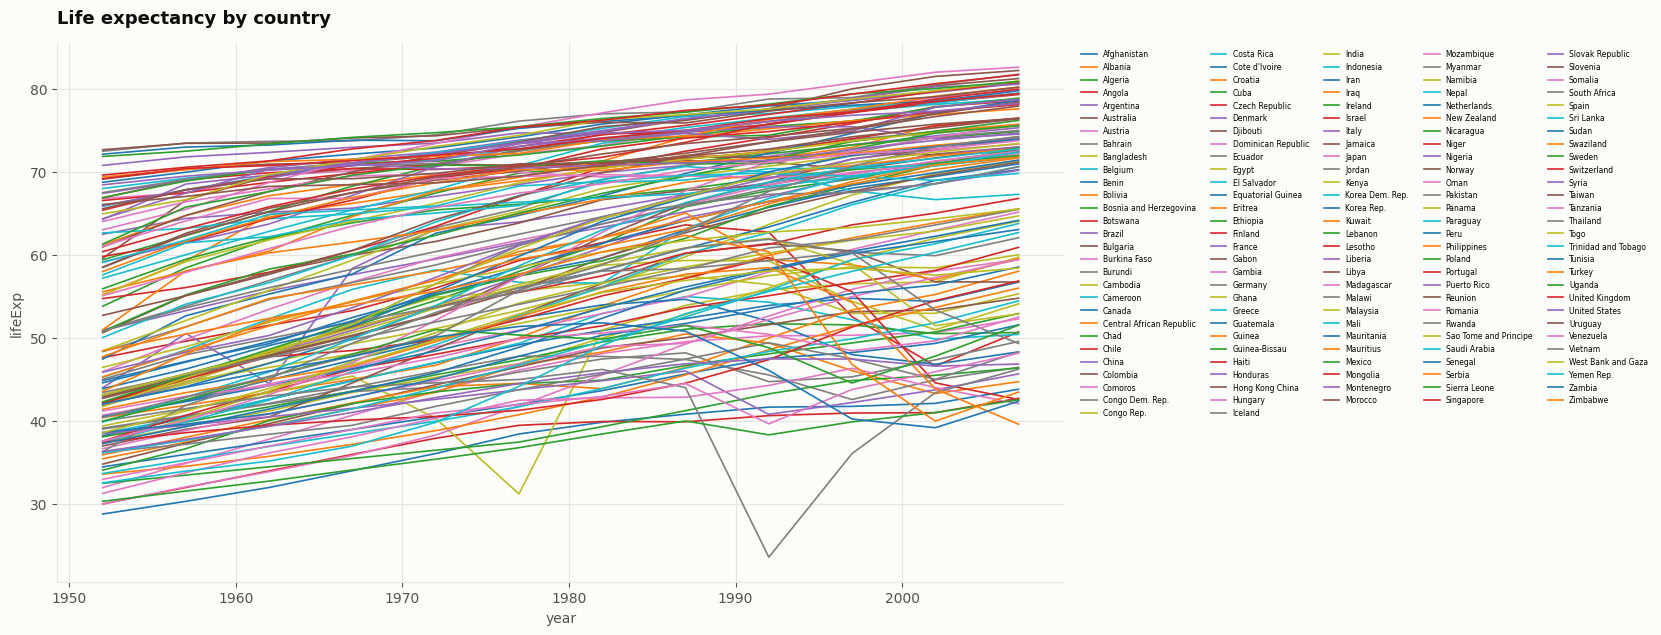

In [4]:
# DELIBERATELY BAD - do not copy.
fig, ax = plt.subplots(figsize=(13, 7))

for country, g in gap.groupby("country"):
    ax.plot(g["year"], g["lifeExp"], linewidth=1.2, label=country)

ax.set_title("Life expectancy by country")  # describes the axes, says nothing
ax.set_xlabel("year")
ax.set_ylabel("lifeExp")
ax.legend(ncol=5, fontsize=5.5, loc="upper left", bbox_to_anchor=(1.01, 1.0))

save(fig, "task2_01_messy_spaghetti")
plt.show()

### Everything wrong with it

1. **No message.** The title names the axes ("life expectancy by country"). It does not tell the reader what to
   take away, because the chart does not have one thing to say.
2. **142 lines is spaghetti.** The lines cross hundreds of times. You can see that life expectancy generally
   went up, and that there is a sharp dip somewhere around 1992 — but you cannot tell *which* country any line
   belongs to.
3. **The legend is useless.** 142 entries in 5.5-point type, and it is bigger than the chart. The default colour
   cycle only has **10 colours**, so each colour is reused about 14 times: the legend literally cannot tell you
   which line is which. That is an automatic deduction in the marking guide — a legend with more entries than
   a reader could use.
4. **Colour means nothing.** It is assigned alphabetically, so Afghanistan and Germany can share a colour. The
   rainbow is decoration pretending to be information.
5. **The interesting stories are invisible.** The collapse in Rwanda, the HIV/AIDS crash in southern Africa, the
   steady climb in East Asia — they are all in there, buried under everything else.
6. **Raw column names as labels** (`lifeExp`, `year`) and no units.

---

# Step 2a — Fix 1: aggregate (one line per continent)

**Processing first.** The small tidy table behind this chart is 5 continents × 12 years. I use the **simple
average of the countries** in each continent (every country counts once). A population-weighted average would
answer a different question — "how long does the *average person* live" — and would be dominated by China and
India. I state the choice on the chart.

In [5]:
by_cont = (
    gap.groupby(["continent", "year"])["lifeExp"].mean().round(1).unstack("year")
)
by_cont

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
continent,,,,,,,,,,,,
Africa,39.1,41.3,43.3,45.3,47.5,49.6,51.6,53.3,53.6,53.6,53.3,54.8
Americas,53.3,56.0,58.4,60.4,62.4,64.4,66.2,68.1,69.6,71.2,72.4,73.6
Asia,46.3,49.3,51.6,54.7,57.3,59.6,62.6,64.9,66.5,68.0,69.2,70.7
Europe,64.4,66.7,68.5,69.7,70.8,71.9,72.8,73.6,74.4,75.5,76.7,77.6
Oceania,69.3,70.3,71.1,71.3,71.9,72.9,74.3,75.3,76.9,78.2,79.7,80.7


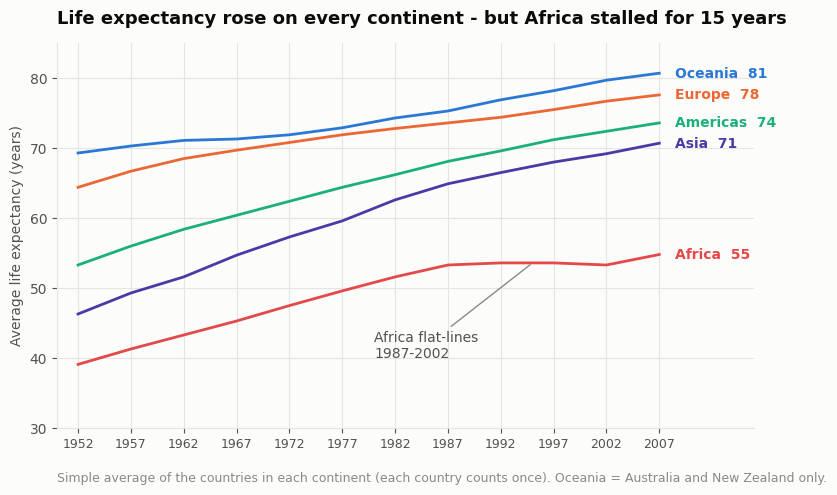

In [6]:
# Sort the continents by their final value so the end labels read top to bottom.
order = by_cont[2007].sort_values(ascending=False).index
colours = dict(zip(order, [BLUE, ORANGE, AQUA, VIOLET, RED]))

fig, ax = plt.subplots(figsize=(9, 5))
for cont in order:
    ax.plot(by_cont.columns, by_cont.loc[cont], color=colours[cont], zorder=3)
    # Direct labels at the end of each line instead of a legend.
    ax.text(
        2008.5,
        by_cont.loc[cont, 2007],
        f"{cont}  {by_cont.loc[cont, 2007]:.0f}",
        color=colours[cont],
        fontsize=10,
        fontweight="bold",
        va="center",
    )

# The flat stretch is the story - mark it.
ax.annotate(
    "Africa flat-lines\n1987-2002",
    xy=(1995, 53.6),
    xytext=(1980, 40),
    fontsize=10,
    color=INK_SOFT,
    arrowprops={"arrowstyle": "-", "color": INK_MUTED, "linewidth": 1},
)

ax.set_title("Life expectancy rose on every continent - but Africa stalled for 15 years")
ax.set_ylabel("Average life expectancy (years)")
ax.set_xlim(1950, 2016)
ax.set_ylim(30, 85)
ax.set_xticks(range(1952, 2008, 5))
ax.tick_params(axis="x", labelsize=9)
footnote(
    ax,
    "Simple average of the countries in each continent (each country counts once). "
    "Oceania = Australia and New Zealand only.",
    y=-0.14,
)

save(fig, "task2_02a_aggregate_continents")
plt.show()

**Why this chart type:** a **line chart**, because the x-axis is time — ordered, evenly spaced — and the question
is how each group *changes*. Five lines is few enough to label directly, so there is no legend to decode. Colour
here means continent, and nothing else.

The y-axis does not start at zero. That is fine for a line: unlike a bar, a line encodes values by *position*,
not length, and starting at 0 would squash the differences we want to see into the top third of the chart.

---

# Step 2b — Fix 2: highlight (all 142 lines, 3 in colour)

I picked three countries that tell three different stories:

- **South Korea** (`Korea Rep.`) — the steadiest, fastest climb: from 47.5 to 78.6 years.
- **Botswana** — a strong rise until the late 1980s, then the HIV/AIDS epidemic took away over 15 years.
- **Rwanda** — the sharpest single fall in the dataset: 23.6 years in 1992, the period of the civil war and the
  1994 genocide.

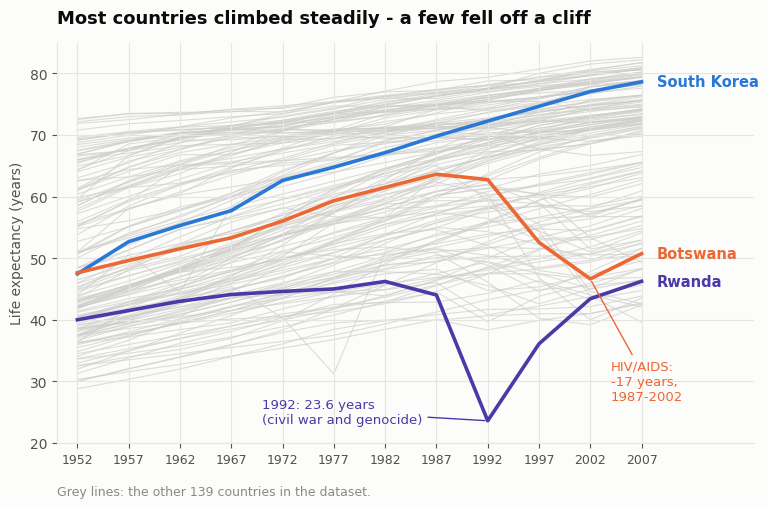

In [7]:
picks = {"Korea Rep.": BLUE, "Botswana": ORANGE, "Rwanda": VIOLET}
labels = {"Korea Rep.": "South Korea", "Botswana": "Botswana", "Rwanda": "Rwanda"}

fig, ax = plt.subplots(figsize=(9, 5.2))

# 1. Context: every country, in quiet grey, drawn first so it sits behind.
for country, g in gap.groupby("country"):
    ax.plot(g["year"], g["lifeExp"], color=QUIET, linewidth=0.8, alpha=0.7, zorder=1)

# 2. The message: three countries in colour, labelled directly.
for country, colour in picks.items():
    g = gap[gap["country"] == country]
    ax.plot(g["year"], g["lifeExp"], color=colour, linewidth=2.6, zorder=3)
    ax.text(
        2008.5,
        g["lifeExp"].iloc[-1],
        labels[country],
        color=colour,
        fontsize=10.5,
        fontweight="bold",
        va="center",
    )

# Label the two events, not every point.
ax.annotate(
    "1992: 23.6 years\n(civil war and genocide)",
    xy=(1992, 23.6),
    xytext=(1970, 25),
    fontsize=9.5,
    color=VIOLET,
    va="center",
    arrowprops={"arrowstyle": "-", "color": VIOLET, "linewidth": 1},
)
ax.annotate(
    "HIV/AIDS:\n-17 years,\n1987-2002",
    xy=(2002, 46.6),
    xytext=(2004, 30),
    fontsize=9.5,
    color=ORANGE,
    va="center",
    arrowprops={"arrowstyle": "-", "color": ORANGE, "linewidth": 1},
)

ax.set_title("Most countries climbed steadily - a few fell off a cliff")
ax.set_ylabel("Life expectancy (years)")
ax.set_xlim(1950, 2018)
ax.set_ylim(20, 85)
ax.set_xticks(range(1952, 2008, 5))
ax.tick_params(axis="x", labelsize=9)
footnote(ax, "Grey lines: the other 139 countries in the dataset.", y=-0.13)

save(fig, "task2_02b_highlight_three")
plt.show()

**Why this chart type:** still a **line chart** over time, but colour is now spent on only three lines. Grey is
doing real work: it keeps all 142 countries on the chart as *context* (so you can see a country is unusual)
without competing for attention. Direct labels replace the legend entirely.

---

# Step 3 — Comparing (a) and (b)

| | (a) Aggregate | (b) Highlight |
|---|---|---|
| **Shows well** | Big-picture differences between regions; the size and persistence of the gap between Africa and Europe; Africa's 15-year stall | Individual stories and outliers; how unusual a country is relative to *all* the others; the true range of the data |
| **Cannot show** | Any single country. Averaging **hides** the extremes — Rwanda's 1992 collapse barely dents the Africa line, because it is averaged with 51 other countries. It also hides how widely countries vary within a continent | Group patterns. You cannot read "how is Asia doing?" from it, and the three highlighted countries are my choice — a reader only sees what I chose to colour |
| **Risk** | Looks smoother and more certain than reality | Cherry-picking: three dramatic countries can make the world look more chaotic than it was |

They answer different questions. (a) answers *"how did regions change?"*; (b) answers *"which countries broke
the pattern?"*. Neither can replace the other — which is exactly why the spaghetti chart, which tries to answer
both at once, answers neither.

---

# Watch out: `gdpPercap` is extremely skewed

Before using GDP in Step 4, look at its distribution. The same data is drawn twice: once on a normal
(linear) axis, once with log-spaced bins on a log axis.

In [8]:
gdp = gap["gdpPercap"]
print(gdp.describe().round(0))
print()
print("Mean / median:", round(gdp.mean() / gdp.median(), 1))
print("Largest values:")
print(gap.nlargest(3, "gdpPercap")[["country", "year", "gdpPercap"]].round(0).to_string(index=False))

count      1704.0
mean       7215.0
std        9857.0
min         241.0
25%        1202.0
50%        3532.0
75%        9325.0
max      113523.0
Name: gdpPercap, dtype: float64

Mean / median: 2.0
Largest values:
country  year  gdpPercap
 Kuwait  1957   113523.0
 Kuwait  1972   109348.0
 Kuwait  1952   108382.0


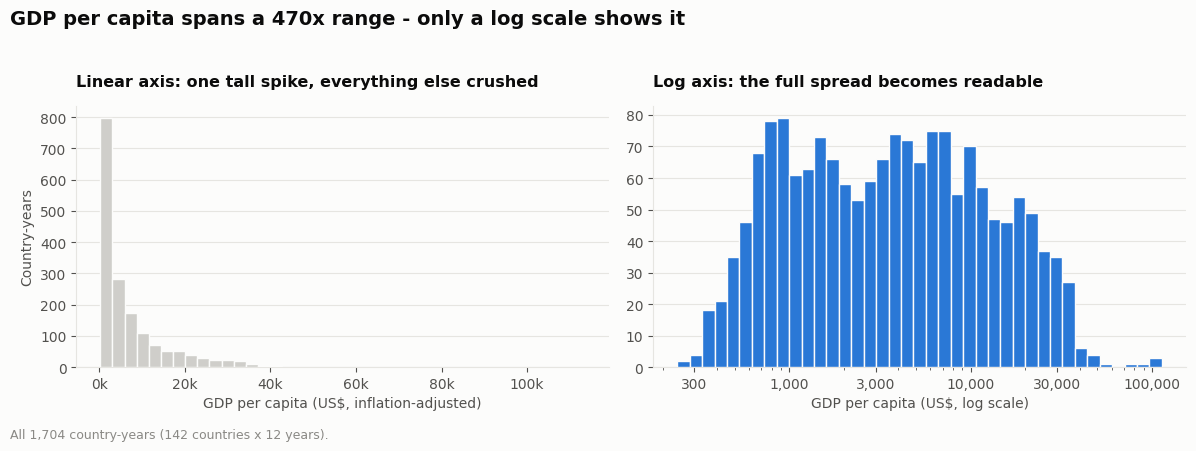

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# LEFT: linear axis.
left = axes[0]
left.hist(gdp, bins=40, color=QUIET, edgecolor=SURFACE, linewidth=1, zorder=3)
left.set_title("Linear axis: one tall spike, everything else crushed", fontsize=11.5)
left.set_xlabel("GDP per capita (US$, inflation-adjusted)")
left.set_ylabel("Country-years")
left.xaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
left.xaxis.grid(False)

# RIGHT: log axis with log-spaced bins - each bin covers the same RATIO of incomes.
right = axes[1]
bins = np.logspace(np.log10(gdp.min()), np.log10(gdp.max()), 40)
right.hist(gdp, bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=1, zorder=3)
right.set_xscale("log")
right.set_title("Log axis: the full spread becomes readable", fontsize=11.5)
right.set_xlabel("GDP per capita (US$, log scale)")
right.set_xticks([300, 1000, 3000, 10000, 30000, 100000])
right.xaxis.set_major_formatter(lambda v, p: f"{v:,.0f}")
right.xaxis.grid(False)

for ax in axes:
    ax.set_axisbelow(True)

fig.suptitle(
    "GDP per capita spans a 470x range - only a log scale shows it",
    x=0.005,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=INK,
)
fig.text(
    0.005,
    0.005,
    "All 1,704 country-years (142 countries x 12 years).",
    fontsize=9,
    color=INK_MUTED,
)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
save(fig, "task2_03_gdp_skew_linear_vs_log")
plt.show()

**What the log scale does.** On a linear axis, the gap from \$300 to \$3,000 is drawn tiny and the gap from
\$30,000 to \$100,000 is drawn huge. Most countries are below \$10,000, so they all pile into the first two
bins and the chart is mostly empty space created by a handful of very rich country-years (Kuwait's oil
economy in the 1950s–70s reaches \$113,523).

A log axis spaces values by **ratio** instead of difference: \$300 → \$3,000 is the same distance as
\$3,000 → \$30,000, because each is a 10× step. That matches how income actually works — a \$500 rise
changes everything for a country at \$500 and almost nothing for one at \$40,000. On the log axis the
distribution becomes a broad hump you can actually read.

**Decision:** I use a log scale for GDP in Step 4. Two conditions make that honest: the axis is clearly
labelled as log, and the chart is a line chart, not a bar chart — a bar on a log axis has no meaningful
zero, so its length would be meaningless.

---

# Step 4 — Has the gap between the richest and poorest countries narrowed since 1952?

**Defining "richest" and "poorest".** The obvious choice — the single richest country divided by the single
poorest — is a trap. In 1952 the richest country is Kuwait at \$108,382, an oil outlier more than 7× the
*second*-richest. Max/min would mostly be measuring Kuwait.

So I use the **90th and 10th percentiles** of the 142 countries each year: the line above which the richest 10%
of countries sit, and below which the poorest 10% sit. The gap is their **ratio**, because for income a ratio is
the meaningful comparison (see the log-scale discussion above).

In [10]:
yearly = gap.groupby("year")["gdpPercap"]
income_gap = pd.DataFrame(
    {
        "poorest_10pct": yearly.quantile(0.10),
        "richest_10pct": yearly.quantile(0.90),
        "max_over_min": yearly.max() / yearly.min(),
    }
)
income_gap["ratio_90_10"] = income_gap["richest_10pct"] / income_gap["poorest_10pct"]
income_gap.round(1)

,poorest_10pct,richest_10pct,max_over_min,ratio_90_10
year,,,,
1952,495.0,7255.3,362.7,14.7
1957,576.0,9667.9,337.9,16.8
1962,603.1,10967.2,268.7,18.2
1967,701.6,14060.6,231.8,20.0
1972,724.1,16606.2,306.3,22.9
1977,741.5,19091.7,159.7,25.7
1982,789.7,19467.7,79.5,24.7
1987,738.0,21866.5,81.9,29.6
1992,737.3,24752.2,100.7,33.6


The table already answers the question, and it shows why the definition matters: the crude **max/min**
ratio *falls* (363× → 178×) only because Kuwait's oil wealth came back down to earth. The robust **90/10
ratio** more than **doubles**, from 14.7× to 37.9×. Now the chart.

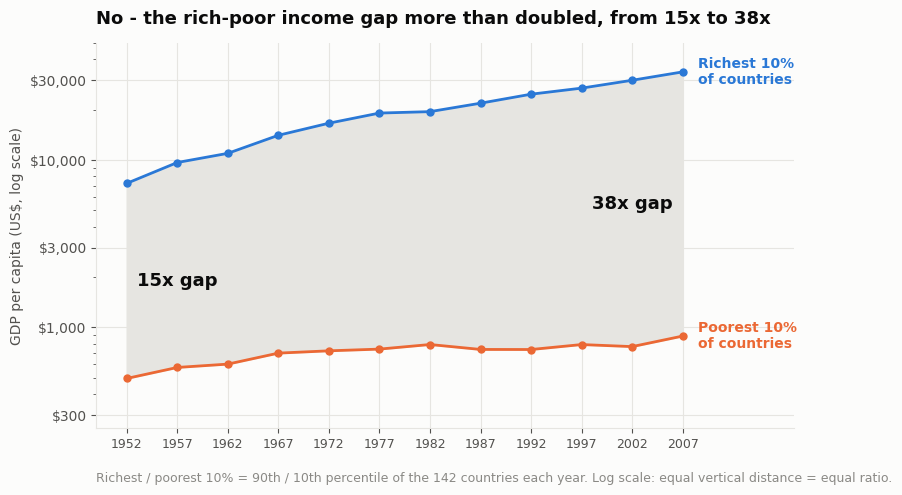

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
years = income_gap.index

# The gap itself, shaded in quiet grey, so the eye reads the space between the lines.
ax.fill_between(years, income_gap["poorest_10pct"], income_gap["richest_10pct"], color=GRID, zorder=1)

ax.plot(years, income_gap["richest_10pct"], color=BLUE, marker="o", markersize=5, zorder=3)
ax.plot(years, income_gap["poorest_10pct"], color=ORANGE, marker="o", markersize=5, zorder=3)

ax.text(2008.5, income_gap.loc[2007, "richest_10pct"], "Richest 10%\nof countries",
        color=BLUE, fontweight="bold", fontsize=10, va="center")
ax.text(2008.5, income_gap.loc[2007, "poorest_10pct"], "Poorest 10%\nof countries",
        color=ORANGE, fontweight="bold", fontsize=10, va="center")

# Label only the two ratios that make the argument: start and end.
for yr in (1952, 2007):
    mid = np.sqrt(income_gap.loc[yr, "richest_10pct"] * income_gap.loc[yr, "poorest_10pct"])
    x_pos, align = (yr + 1, "left") if yr == 1952 else (yr - 1, "right")
    ax.text(x_pos, mid, f"{income_gap.loc[yr, 'ratio_90_10']:.0f}x gap", ha=align, va="center",
            fontsize=13, fontweight="bold", color=INK)

ax.set_yscale("log")
ax.set_yticks([300, 1000, 3000, 10000, 30000])
ax.yaxis.set_major_formatter(lambda v, p: f"${v:,.0f}")
ax.yaxis.set_minor_formatter(lambda v, p: "")
ax.set_ylim(250, 50000)
ax.set_xlim(1949, 2018)
ax.set_xticks(range(1952, 2008, 5))
ax.tick_params(axis="x", labelsize=9)
ax.set_title("No - the rich-poor income gap more than doubled, from 15x to 38x")
ax.set_ylabel("GDP per capita (US$, log scale)")
footnote(
    ax,
    "Richest / poorest 10% = 90th / 10th percentile of the 142 countries each year. "
    "Log scale: equal vertical distance = equal ratio.",
    y=-0.14,
)

save(fig, "task2_04_rich_poor_gap")
plt.show()

### Justification

- **Line chart**, because the question is about change over an ordered time axis — "has it *narrowed since*
  1952" is a trend question.
- **Two lines plus a shaded band**, because "gap" is the distance *between* two things. Showing the two
  boundaries and shading the space between them makes the gap itself the visible object. Two lines is few
  enough to label directly — no legend.
- **Log scale**, because a gap in income is a ratio, and on a log axis the vertical width of the band *is* the
  ratio. On a linear axis the poorest line would sit flat on the floor at a few hundred dollars and the gap
  would look like it was widening purely because rich countries' numbers are large. The log axis is labelled
  in the title of the axis and the footnote.
- **Percentiles, not max and min**, so that one oil state does not decide the answer.

**The answer:** no. The poorest-10% line rose from about \$500 to about \$890 in 55 years (under 2×), while
the richest-10% line rose from about \$7,300 to \$33,600 (more than 4.5×). The band visibly widens, and the ratio went from 15× to 38×.
(For contrast, the *life expectancy* gap between the top and bottom 10% of countries stayed roughly
constant at about 30 years throughout — health caught up in absolute terms far more than income did.)